# Disaster Analysis Pipeline
Earthquake events scraped from ReliefWeb

In [15]:
import json, re, csv
from datetime import datetime
from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import spacy
import plotly.graph_objects as go
from plotly.subplots import make_subplots

nlp = spacy.load('en_core_web_sm')
analyzer = SentimentIntensityAnalyzer()

with open('disasters_data.json') as f:
    disasters = json.load(f)

for d in disasters:
    print(d['label'], '-', len(d.get('all_update_headlines',[])), 'headlines')

Indonesia Earthquake Nov 2022 - 82 headlines
Indonesia Earthquake Nov 2008 - 21 headlines
Myanmar Earthquake Mar 2025 - 300 headlines
China Earthquake Jun 2012 - 11 headlines


## Task 2.1 - Response Delta Calculation
Delta_T = T_MediaPeak - T_SystemAlert

In [16]:
event_dates = {
    'Indonesia Earthquake Nov 2022': datetime(2022,11,21),
    'Indonesia Earthquake Nov 2008': datetime(2008,11,17),
    'Myanmar Earthquake Mar 2025': datetime(2025,3,28),
    'China Earthquake Jun 2012': datetime(2012,6,30),
}

response_deltas = []
for event in disasters:
    label = event['label']
    alert_date = event_dates.get(label)
    dates = Counter()
    for h in event.get('all_update_headlines', []):
        d = h.get('date','')
        if d:
            dates[d.split('T')[0]] += 1

    peak_date = 'N/A'
    peak_count = 0
    delta = 'N/A'
    if dates:
        peak_date, peak_count = dates.most_common(1)[0]
        if alert_date:
            delta = (datetime.strptime(peak_date,'%Y-%m-%d') - alert_date).days

    response_deltas.append({'label': label, 'alert': alert_date, 'peak': peak_date,
                            'peak_count': peak_count, 'delta': delta,
                            'total': sum(dates.values())})
    print(f'{label}')
    print(f'  System Alert: {alert_date.strftime("%Y-%m-%d") if alert_date else "N/A"}')
    print(f'  Media Peak: {peak_date} ({peak_count} articles)')
    print(f'  Delta_T: {delta} days')
    print(f'  Total articles: {sum(dates.values())}')
    print()

Indonesia Earthquake Nov 2022
  System Alert: 2022-11-21
  Media Peak: 2022-11-22 (9 articles)
  Delta_T: 1 days
  Total articles: 82

Indonesia Earthquake Nov 2008
  System Alert: 2008-11-17
  Media Peak: 2008-11-17 (6 articles)
  Delta_T: 0 days
  Total articles: 21

Myanmar Earthquake Mar 2025
  System Alert: 2025-03-28
  Media Peak: 2025-04-17 (14 articles)
  Delta_T: 20 days
  Total articles: 300

China Earthquake Jun 2012
  System Alert: 2012-06-30
  Media Peak: 2012-07-02 (2 articles)
  Delta_T: 2 days
  Total articles: 11



## Task 2.2 - Entity Recognition (NER) using spaCy
Extracting NGOs, Governments, Private Agencies, deaths, losses, relief funds from headlines

In [17]:
ner_results = []
for event in disasters:
    headlines = event.get('all_update_headlines',[]) + event.get('headlines_from_main_page',[])
    text = ' '.join(h.get('title','') for h in headlines)
    text += ' ' + ' '.join(h.get('source','') for h in headlines)
    text += ' ' + event.get('disaster_description','')

    doc = nlp(text[:100000])

    orgs = Counter()
    locations = Counter()
    money = []
    for ent in doc.ents:
        if ent.label_ == 'ORG':
            orgs[ent.text.strip()] += 1
        elif ent.label_ == 'GPE':
            locations[ent.text.strip()] += 1
        elif ent.label_ == 'MONEY':
            money.append(ent.text.strip())

    deaths = re.findall(r'(\d[\d,]*)\s*(?:people\s+)?(?:dead|killed|deaths?|fatalities)', text, re.I)
    funds = re.findall(r'(?:US?\$|\u20ac|EUR|USD)\s*([\d,.]+\s*(?:million|billion)?)', text, re.I)

    result = {'label': event['label'], 'orgs': dict(orgs.most_common(15)),
              'locations': dict(locations.most_common(10)),
              'money': money, 'deaths': deaths, 'funds': funds}
    ner_results.append(result)

    print(f'{event["label"]}')
    print(f'  Organizations (spaCy): {dict(orgs.most_common(10))}')
    print(f'  Locations: {dict(locations.most_common(5))}')
    if money: print(f'  Money mentions: {money[:10]}')
    if deaths: print(f'  Death figures: {deaths}')
    if funds: print(f'  Relief funds: {funds}')
    print()

Indonesia Earthquake Nov 2022
  Organizations (spaCy): {'BMKG': 6, 'the Pacific: Weekly': 5, 'ASEAN Weekly Disaster Update': 4, 'Cianjur Regency': 4, 'ECHO': 4, 'GDACS': 3, 'Madrasahs and Returning Students': 2, 'Response Cianjur': 2, 'UTC': 2, 'the Indonesian National Board for Disaster Management': 2}
  Locations: {'Indonesia': 50, 'BNPB': 8, 'West Java': 6, 'GDACS': 4, 'USGS': 4}
  Money mentions: ['270bn', '500,000', '270bn', '37 per cent']
  Death figures: ['327']
  Relief funds: ['270', '500,000 ', '270']

Indonesia Earthquake Nov 2008
  Organizations (spaCy): {'Snapshot on Earthquakes': 2, 'the UN SG': 2, 'CWS': 2, 'Sulawesi quake CWS': 1, "Turkish Red Crescent's": 1, 'Jakarta Post CWS': 1, 'Turkish Red Crescent': 1, 'CFE-DM Reuters Reuters': 1, 'ReliefWeb NOAA': 1, 'DPA': 1}
  Locations: {'Indonesia': 24, 'Tsunami': 2, 'Gorontalo Province': 2, 'Sulawesi': 2, 'Georgia': 1}

Myanmar Earthquake Mar 2025
  Organizations (spaCy): {'UNHCR': 15, 'ECHO': 9, 'UNFPA': 6, 'GIEWS Country':

## Task 2.3 - Sentiment Volatility
Comparing tone of historical vs recent disaster headlines

In [18]:
sentiment_results = {}
for event in disasters:
    scores = []
    for h in event.get('all_update_headlines',[]):
        title = h.get('title','')
        if len(title) < 10: continue
        vs = analyzer.polarity_scores(title)
        label = 'Positive' if vs['compound']>=0.05 else ('Negative' if vs['compound']<=-0.05 else 'Neutral')
        scores.append({'title': title, 'score': vs['compound'], 'label': label})
    sentiment_results[event['label']] = scores

for name, scores in sentiment_results.items():
    if not scores: continue
    avg = sum(s['score'] for s in scores) / len(scores)
    pos = sum(1 for s in scores if s['label']=='Positive')
    neg = sum(1 for s in scores if s['label']=='Negative')
    neu = sum(1 for s in scores if s['label']=='Neutral')
    print(f'{name}')
    print(f'  Headlines analyzed: {len(scores)}')
    print(f'  Average sentiment: {avg:+.4f}')
    print(f'  Positive: {pos} | Neutral: {neu} | Negative: {neg}')
    print()

Indonesia Earthquake Nov 2022
  Headlines analyzed: 82
  Average sentiment: -0.0614
  Positive: 17 | Neutral: 42 | Negative: 23

Indonesia Earthquake Nov 2008
  Headlines analyzed: 21
  Average sentiment: -0.1258
  Positive: 2 | Neutral: 12 | Negative: 7

Myanmar Earthquake Mar 2025
  Headlines analyzed: 300
  Average sentiment: -0.0674
  Positive: 42 | Neutral: 178 | Negative: 80

China Earthquake Jun 2012
  Headlines analyzed: 11
  Average sentiment: -0.0377
  Positive: 2 | Neutral: 5 | Negative: 4



In [19]:
pairs = [
    ('Indonesia', 'Indonesia Earthquake Nov 2022', 'Indonesia Earthquake Nov 2008'),
    ('Myanmar/China', 'Myanmar Earthquake Mar 2025', 'China Earthquake Jun 2012'),
]

for region, recent_key, hist_key in pairs:
    recent = sentiment_results[recent_key]
    hist = sentiment_results[hist_key]
    r_avg = sum(s['score'] for s in recent)/len(recent) if recent else 0
    h_avg = sum(s['score'] for s in hist)/len(hist) if hist else 0
    diff = r_avg - h_avg

    print(f'{region}:')
    print(f'  Recent avg: {r_avg:+.4f} | Historical avg: {h_avg:+.4f}')
    if diff < -0.05: print(f'  -> Recent is MORE ALARMIST (shift: {diff:+.4f})')
    elif diff > 0.05: print(f'  -> Recent is MORE ANALYTICAL (shift: {diff:+.4f})')
    else: print(f'  -> Similar tone (shift: {diff:+.4f})')
    print()

Indonesia:
  Recent avg: -0.0614 | Historical avg: -0.1258
  -> Recent is MORE ANALYTICAL (shift: +0.0644)

Myanmar/China:
  Recent avg: -0.0674 | Historical avg: -0.0377
  -> Similar tone (shift: -0.0297)



## Task 3.1 - Forgotten Crisis Index
FCI = News Volume / Population Affected

In [20]:
fci_results = []
for event in disasters:
    reports = event.get('total_headlines_all_updates',0) or 0
    pop = event.get('impact',{}).get('total_population_affected',0) or 1
    fci = (reports / pop) * 1000000
    fci_results.append({'label': event['label'], 'reports': reports, 'pop': pop, 'fci': round(fci,2)})

fci_results.sort(key=lambda x: x['fci'], reverse=True)
for r in fci_results:
    print(f'{r["label"]}')
    print(f'  Reports: {r["reports"]} | Population: {r["pop"]:,} | FCI: {r["fci"]}')
    print()

print(f'Most covered: {fci_results[0]["label"]} (FCI={fci_results[0]["fci"]})')
print(f'Least covered: {fci_results[-1]["label"]} (FCI={fci_results[-1]["fci"]})')

Indonesia Earthquake Nov 2008
  Reports: 21 | Population: 15,083 | FCI: 1392.3

Indonesia Earthquake Nov 2022
  Reports: 82 | Population: 242,000 | FCI: 338.84

China Earthquake Jun 2012
  Reports: 11 | Population: 155,000 | FCI: 70.97

Myanmar Earthquake Mar 2025
  Reports: 300 | Population: 17,000,000 | FCI: 17.65

Most covered: Indonesia Earthquake Nov 2008 (FCI=1392.3)
Least covered: Myanmar Earthquake Mar 2025 (FCI=17.65)


## Task 3.2 - Vulnerability Benchmark
Comparing coping capacity between regions

In [21]:
vuln_data = []
for event in disasters:
    imp = event.get('impact',{})
    mag = imp.get('magnitude',0) or 0
    deaths = imp.get('deaths',0) or 0
    pop = imp.get('total_population_affected',0) or 0
    deaths_per_mag = deaths / mag if mag else 0
    coping = mag / (deaths_per_mag + 1)
    vuln_data.append({'label': event['label'], 'mag': mag, 'deaths': deaths,
                     'pop': pop, 'dpm': round(deaths_per_mag,2), 'coping': round(coping,2)})

for v in vuln_data:
    print(f'{v["label"]}')
    print(f'  Magnitude: {v["mag"]} | Deaths: {v["deaths"]:,} | Deaths/Magnitude: {v["dpm"]}')
    print(f'  Coping Score: {v["coping"]}')
    print()

for region, rk, hk in pairs:
    r = next(v for v in vuln_data if v['label']==rk)
    h = next(v for v in vuln_data if v['label']==hk)
    print(f'{region} comparison:')
    print(f'  Recent - Coping: {r["coping"]}, Deaths/Mag: {r["dpm"]}')
    print(f'  Historical - Coping: {h["coping"]}, Deaths/Mag: {h["dpm"]}')
    if r['coping'] > h['coping']: print('  -> Better coping in recent event')
    else: print('  -> Worse coping in recent event')
    print()

Indonesia Earthquake Nov 2022
  Magnitude: 5.6 | Deaths: 327 | Deaths/Magnitude: 58.39
  Coping Score: 0.09

Indonesia Earthquake Nov 2008
  Magnitude: 7.7 | Deaths: 6 | Deaths/Magnitude: 0.78
  Coping Score: 4.33

Myanmar Earthquake Mar 2025
  Magnitude: 7.7 | Deaths: 3,900 | Deaths/Magnitude: 506.49
  Coping Score: 0.02

China Earthquake Jun 2012
  Magnitude: 6.6 | Deaths: 0 | Deaths/Magnitude: 0.0
  Coping Score: 6.6

Indonesia comparison:
  Recent - Coping: 0.09, Deaths/Mag: 58.39
  Historical - Coping: 4.33, Deaths/Mag: 0.78
  -> Worse coping in recent event

Myanmar/China comparison:
  Recent - Coping: 0.02, Deaths/Mag: 506.49
  Historical - Coping: 6.6, Deaths/Mag: 0.0
  -> Worse coping in recent event



## Task 4.1 - Disaster Pulse Dashboard

### Dual-Timeline: News Volume Growth

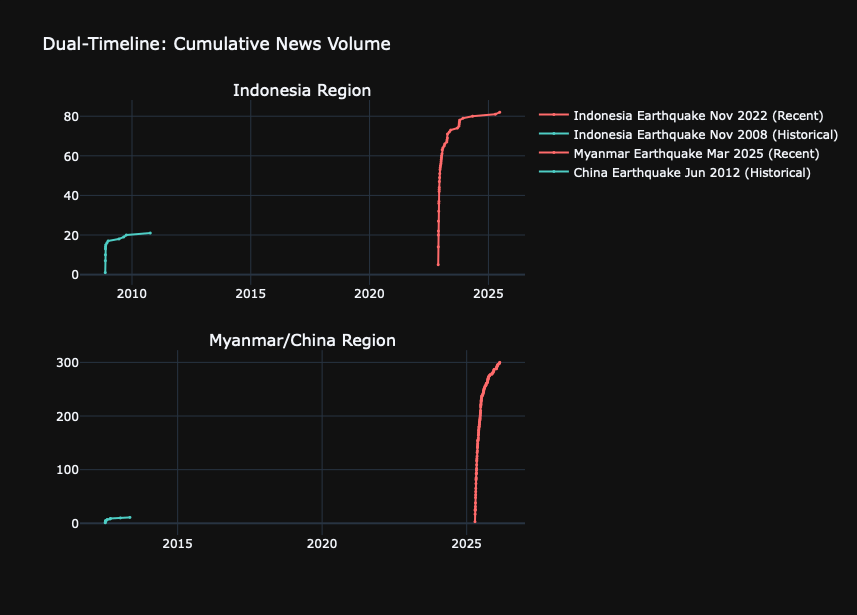

In [22]:
def get_timeline(event):
    dates = Counter()
    for h in event.get('all_update_headlines',[]):
        d = h.get('date','')
        if d: dates[d.split('T')[0]] += 1
    return dates

fig = make_subplots(rows=2, cols=1, subplot_titles=['Indonesia Region', 'Myanmar/China Region'],
                    vertical_spacing=0.15)

colors = {'recent': '#FF6B6B', 'historical': '#4ECDC4'}

for i, (region, rk, hk) in enumerate(pairs):
    for key, color, style in [(rk, colors['recent'], 'Recent'), (hk, colors['historical'], 'Historical')]:
        ev = next(e for e in disasters if e['label']==key)
        dates = get_timeline(ev)
        sorted_dates = sorted(dates.keys())
        cumulative = []
        total = 0
        for d in sorted_dates:
            total += dates[d]
            cumulative.append(total)
        fig.add_trace(go.Scatter(x=sorted_dates, y=cumulative, mode='lines+markers',
                                name=f'{key} ({style})', line=dict(color=color, width=2),
                                marker=dict(size=3)), row=i+1, col=1)

fig.update_layout(height=600, title='Dual-Timeline: Cumulative News Volume',
                  template='plotly_dark')
fig.show()

### Resilience Radar Chart

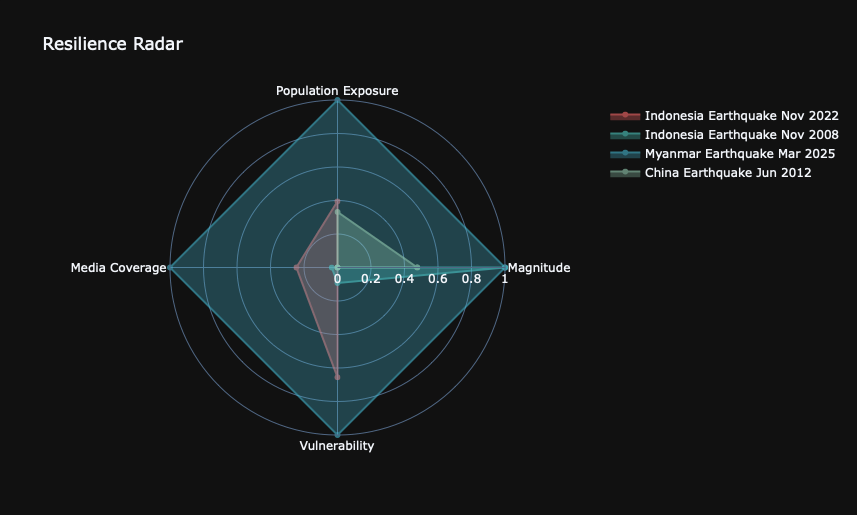

In [23]:
def normalize(val, min_v, max_v):
    if max_v == min_v: return 0.5
    return (val - min_v) / (max_v - min_v)

import math
categories = ['Magnitude', 'Population Exposure', 'Media Coverage', 'Vulnerability']

mags = [v['mag'] for v in vuln_data]
pops = [v['pop'] for v in vuln_data]
reports = [f['reports'] for f in fci_results]
dpms = [v['dpm'] for v in vuln_data]

fig = go.Figure()
event_colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4']

for i, event in enumerate(disasters):
    v = next(x for x in vuln_data if x['label']==event['label'])
    f = next(x for x in fci_results if x['label']==event['label'])
    vals = [
        normalize(v['mag'], min(mags), max(mags)),
        normalize(math.log1p(v['pop']), math.log1p(min(pops)), math.log1p(max(pops))),
        normalize(f['reports'], min(reports), max(reports)),
        normalize(math.log1p(v['dpm']), math.log1p(min(dpms)), math.log1p(max(dpms))),
    ]
    fig.add_trace(go.Scatterpolar(r=vals+[vals[0]], theta=categories+[categories[0]],
                                  fill='toself', name=event['label'],
                                  line_color=event_colors[i], opacity=0.6))

fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0,1])),
                  title='Resilience Radar', template='plotly_dark', height=500)
fig.show()

## Save Results

In [24]:
rows = []
for i, event in enumerate(disasters):
    label = event['label']
    rd = response_deltas[i]
    s = sentiment_results[label]
    avg_s = sum(x['score'] for x in s)/len(s) if s else 0
    fci = next((f for f in fci_results if f['label']==label), {})
    vuln = next((v for v in vuln_data if v['label']==label), {})
    rows.append({'Event': label, 'Delta_T': rd['delta'],
                 'Total Articles': rd['total'], 'Avg Sentiment': round(avg_s,4),
                 'FCI': fci.get('fci',''), 'Coping': vuln.get('coping','')})

with open('analysis_results.csv','w',newline='') as f:
    w = csv.DictWriter(f, fieldnames=rows[0].keys())
    w.writeheader()
    w.writerows(rows)

sent_rows = []
for event in disasters:
    for h in event.get('all_update_headlines',[]):
        t = h.get('title','')
        if len(t) >= 10:
            vs = analyzer.polarity_scores(t)
            lbl = 'Positive' if vs['compound']>=0.05 else ('Negative' if vs['compound']<=-0.05 else 'Neutral')
            sent_rows.append({'Event': event['label'], 'Headline': t,
                              'Score': round(vs['compound'],4), 'Label': lbl})
if sent_rows:
    with open('sentiment_analysis.csv','w',newline='') as f:
        w = csv.DictWriter(f, fieldnames=sent_rows[0].keys())
        w.writeheader()
        w.writerows(sent_rows)

print('Saved analysis_results.csv and sentiment_analysis.csv')

Saved analysis_results.csv and sentiment_analysis.csv
